In [1]:
import os
import pandas as pd
import numpy as np
import librosa
from tqdm import tqdm
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. CARGA DE DATOS Y ANÁLISIS DE DURACIONES
# =====================================================================
PATH_MAESTRO_CSV = r"C:\Users\Usuario\Desktop\UNI MARINA\master\TFM\TFM_resp_dis\combined_metadata_datasets.csv"
PATH_AUDIOS_COUGHVID = r"C:\Users\Usuario\Desktop\UNI MARINA\master\TFM\DATA"
PATH_AUDIOS_FSD50K = r"C:\Users\Usuario\Desktop\UNI MARINA\master\TFM\FSD50K_DATA\FSD50K.dev_audio\FSD50K_negative_class_dataset"

df_maestro = pd.read_csv(PATH_MAESTRO_CSV)
duraciones = []

print("⏳ Extrayendo duraciones exactas de los archivos físicos...")
for idx, row in tqdm(df_maestro.iterrows(), total=len(df_maestro), desc="Audios"):
    uuid = str(row['uuid'])
    if row['dataset_origin'] == 'FSD50K':
        path = os.path.join(PATH_AUDIOS_FSD50K, f"{uuid}.wav")
    else:
        path = os.path.join(PATH_AUDIOS_COUGHVID, f"{uuid}.wav")
        
    if os.path.exists(path):
        try:
            duraciones.append(librosa.get_duration(path=path))
        except: duraciones.append(np.nan)
    else:
        duraciones.append(np.nan)

df_maestro['duration'] = duraciones
df_maestro = df_maestro.dropna(subset=['duration']).reset_index(drop=True)

# --- Mostrar Percentiles ---
print("\n📊 DISTRIBUCIÓN DE DURACIONES:")
print(f"Min: {df_maestro['duration'].min():.2f}s")
print(f"Percentil 25: {df_maestro['duration'].quantile(0.25):.2f}s")
print(f"Mediana (P50): {df_maestro['duration'].quantile(0.50):.2f}s")
print(f"Percentil 75: {df_maestro['duration'].quantile(0.75):.2f}s")
print(f"Percentil 95: {df_maestro['duration'].quantile(0.95):.2f}s")
print(f"Max: {df_maestro['duration'].max():.2f}s")

⏳ Extrayendo duraciones exactas de los archivos físicos...


Audios: 100%|██████████| 10361/10361 [00:04<00:00, 2456.86it/s]


📊 DISTRIBUCIÓN DE DURACIONES:
Min: 0.30s
Percentil 25: 2.00s
Mediana (P50): 5.35s
Percentil 75: 9.84s
Percentil 95: 20.28s
Max: 550.25s


C:\Users\Usuario\AppData\Local\Temp\ipykernel_55868\2452718074.py:55: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Usuario\AppData\Local\Temp\ipykernel_55868\2452718074.py:59: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.savefig('graphs_results_experiments/distribucion_duraciones_tfm.png', dpi=300)
c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


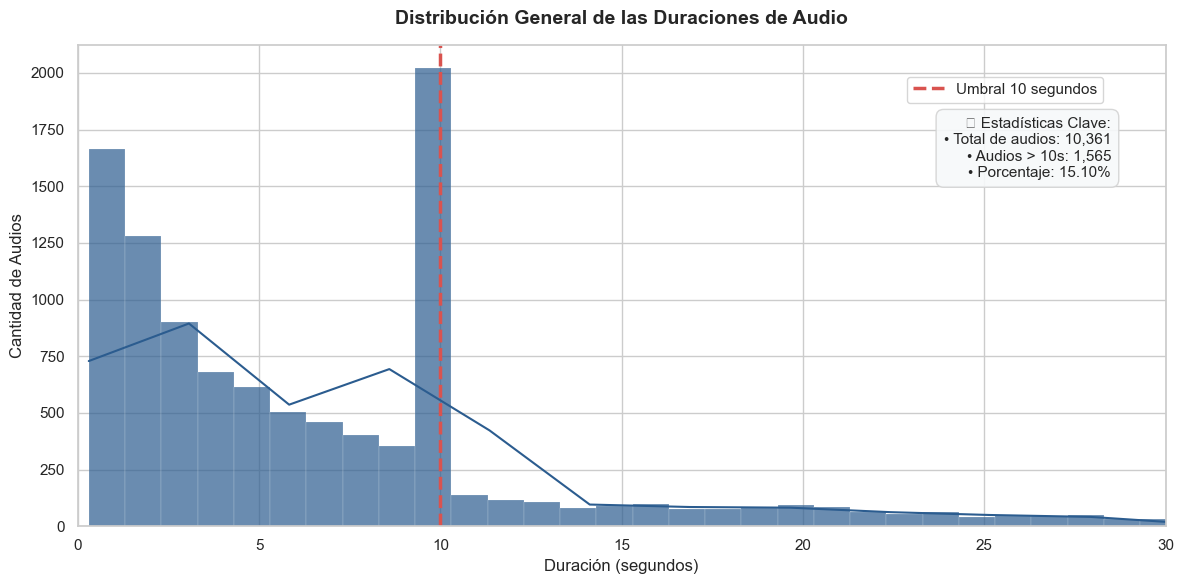

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el estilo visual
sns.set_theme(style='whitegrid')
plt.figure(figsize=(12, 6))

# 2. Calcular métricas exactas para el cuadro de texto
total_audios = len(df_maestro)
audios_mas_10s = (df_maestro['duration'] > 10).sum()
porcentaje_mas_10s = (audios_mas_10s / total_audios) * 100

# 3. Dibujar el histograma (capamos visualmente en 30s para que los outliers gigantes no rompan el gráfico)
# Nota: Los datos reales siguen estando intactos, esto es solo para la escala del gráfico.
sns.histplot(
    data=df_maestro, 
    x='duration', 
    binwidth=1, 
    kde=True, 
    color='#2b5c8f', 
    edgecolor='white',
    alpha=0.7
)

# 4. Limitar el eje X para la visualización (por ejemplo, hasta 30 segundos) si tienes outliers muy grandes
plt.xlim(0, 30)

# 5. Añadir la línea umbral de los 10 segundos
plt.axvline(x=10, color='#d9534f', linestyle='--', linewidth=2.5, label='Umbral 10 segundos')

# 6. Añadir etiquetas y títulos académicos
plt.title('Distribución General de las Duraciones de Audio', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Duración (segundos)', fontsize=12)
plt.ylabel('Cantidad de Audios', fontsize=12)

# 7. Crear el cuadro de texto con las estadísticas clave
info_text = (
    f"📊 Estadísticas Clave:\n"
    f"• Total de audios: {total_audios:,}\n"
    f"• Audios > 10s: {audios_mas_10s:,}\n"
    f"• Porcentaje: {porcentaje_mas_10s:.2f}%"
)

# Colocar el cuadro de texto de forma limpia en la zona superior derecha
plt.gca().text(
    0.95, 0.85, info_text, 
    transform=plt.gca().transAxes, 
    fontsize=11,
    verticalalignment='top', 
    horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#f7f9fa', edgecolor='#d3d3d3', alpha=0.9)
)

plt.legend(loc='upper right', bbox_to_anchor=(0.95, 0.95))
plt.tight_layout()

# Guardar la gráfica en tu carpeta de resultados antes de mostrarla
os.makedirs('graphs_results_experiments', exist_ok=True)
plt.savefig('graphs_results_experiments/distribucion_duraciones_tfm.png', dpi=300)
plt.show()

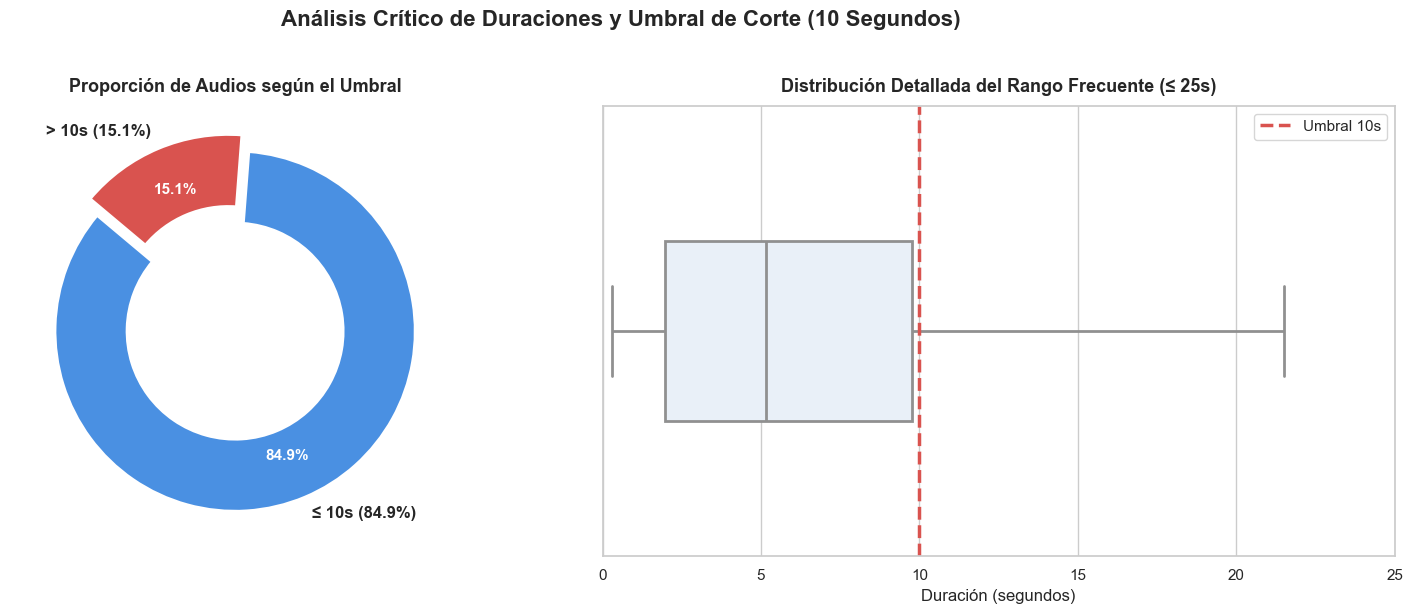

------------------------------------------------------------
📋 RESUMEN DE CONTROL MÁSTER:
   - Volumen Total del Dataset Unificado: 10,361 archivos.
   - Dentro del límite seguro (≤ 10s):    8,796 audios.
   - Requieren segmentación (> 10s):      1,565 audios.
------------------------------------------------------------


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparar los datos para la clasificación binaria
total_audios = len(df_maestro)
mas_de_10s = (df_maestro['duration'] > 10).sum()
menos_o_igual_10s = total_audios - mas_de_10s

porcentaje_mas = (mas_de_10s / total_audios) * 100
porcentaje_menos = (menos_o_igual_10s / total_audios) * 100

# 2. Configurar la figura con dos subgráficos en paralelo (1 fila, 2 columnas)
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Análisis Crítico de Duraciones y Umbral de Corte (10 Segundos)', fontsize=16, fontweight='bold', y=1.02)

# --- GRÁFICO 1: TARTA TIPO DONUT (Proporción respecto al Umbral) ---
labels = [f'≤ 10s ({porcentaje_menos:.1f}%)', f'> 10s ({porcentaje_mas:.1f}%)']
sizes = [menos_o_igual_10s, mas_de_10s]
colors = ['#4a90e2', '#d9534f'] # Azul elegante y Rojo de alerta
explode = (0, 0.1)  # Resaltar los que miden más de 10s

# Dibujar la tarta
wedges, texts, autotexts = axes[0].pie(
    sizes, explode=explode, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=140, pctdistance=0.75,
    textprops=dict(fontsize=12, fontweight='bold'),
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2) # Efecto Donut
)

# Estilizar los textos internos de los porcentajes
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)

axes[0].set_title('Proporción de Audios según el Umbral', fontsize=13, fontweight='bold', pad=10)

# --- GRÁFICO 2: BOXPLOT + STRIPPLOT (Distribución del Rango Frecuente) ---
# Capamos visualmente a 25 segundos para que la caja no se vea minúscula por culpa de los outliers masivos
df_frecuente = df_maestro[df_maestro['duration'] <= 25]

sns.boxplot(
    data=df_frecuente, 
    x='duration', 
    ax=axes[1], 
    color='#e6f0fa', 
    width=0.4,
    linewidth=2,
    fliersize=0 # Ocultamos los puntos sueltos extremos para no saturar
)

# Añadir una línea roja discontinua que marque el umbral exacto en el gráfico de caja
axes[1].axvline(x=10, color='#d9534f', linestyle='--', linewidth=2.5, label='Umbral 10s')

axes[1].set_title('Distribución Detallada del Rango Frecuente (≤ 25s)', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Duración (segundos)', fontsize=12)
axes[1].set_xlim(0, 25)
axes[1].legend(loc='upper right')

# 3. Ajustar diseño y guardar en alta resolución
plt.tight_layout()
os.makedirs('graphs_results_experiments', exist_ok=True)
plt.savefig('graphs_results_experiments/analisis_donuts_boxplot_duraciones.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Reporte rápido impreso en consola por debajo del gráfico
print("-" * 60)
print(f"📋 RESUMEN DE CONTROL MÁSTER:")
print(f"   - Volumen Total del Dataset Unificado: {total_audios:,} archivos.")
print(f"   - Dentro del límite seguro (≤ 10s):    {menos_o_igual_10s:,} audios.")
print(f"   - Requieren segmentación (> 10s):      {mas_de_10s:,} audios.")
print("-" * 60)

🔍 AUDITORÍA CRÍTICA: DURACIONES SEGÚN LA CLASE

📊 Distribución para TOS (Clase Positiva):
   - Cantidad total: 2816 audios
   - Mediana:        9.72 segundos
   - Percentil 75:   9.90 segundos
   - Percentil 95:   9.96 segundos
   - Máximo absoluto:13.68 segundos

📊 Distribución para NO-TOS (Controles/Ruido):
   - Cantidad total: 7545 audios
   - Mediana:        3.39 segundos
   - Percentil 75:   8.52 segundos
   - Percentil 95:   22.10 segundos
   - Máximo absoluto:550.25 segundos


C:\Users\Usuario\AppData\Local\Temp\ipykernel_55868\2510522280.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_maestro[df_maestro['duration'] <= 25], x='duration', y='label', orient='h', palette='Set2')


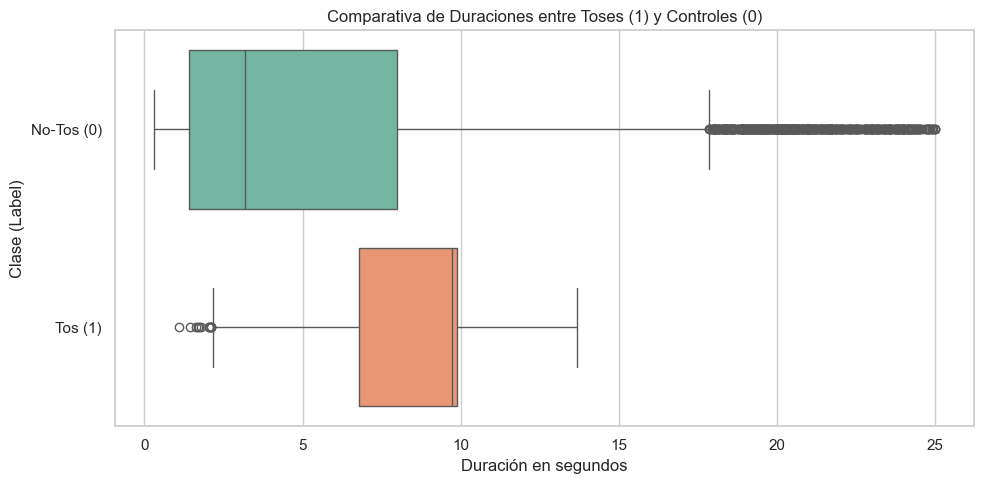


✂️ APLICANDO SEGMENTACIÓN ASIMÉTRICA SEGURO
✅ Dataset listo. Estructura final expandida a 10917 registros.

🚀 ¡Archivos de metadatos segmentados y blindados guardados con éxito!


In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold

# =====================================================================
# 1. ANÁLISIS CRÍTICO: DURACIÓN VS CLASE (TOS vs NO-TOS)
# =====================================================================
print("=" * 70)
print("🔍 AUDITORÍA CRÍTICA: DURACIONES SEGÚN LA CLASE")
print("=" * 70)

for label_code, label_name in [(1, 'TOS (Clase Positiva)'), (0, 'NO-TOS (Controles/Ruido)')]:
    sub_df = df_maestro[df_maestro['label'] == label_code]
    print(f"\n📊 Distribución para {label_name}:")
    print(f"   - Cantidad total: {len(sub_df)} audios")
    print(f"   - Mediana:        {sub_df['duration'].median():.2f} segundos")
    print(f"   - Percentil 75:   {sub_df['duration'].quantile(0.75):.2f} segundos")
    print(f"   - Percentil 95:   {sub_df['duration'].quantile(0.95):.2f} segundos")
    print(f"   - Máximo absoluto:{sub_df['duration'].max():.2f} segundos")

# Visualización comparativa para la memoria del TFM
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_maestro[df_maestro['duration'] <= 25], x='duration', y='label', orient='h', palette='Set2')
plt.title('Comparativa de Duraciones entre Toses (1) y Controles (0)')
plt.xlabel('Duración en segundos')
plt.ylabel('Clase (Label)')
plt.yticks([0, 1], ['No-Tos (0)', 'Tos (1)'])
plt.tight_layout()
plt.savefig('graphs_results_experiments/duraciones_vs_label.png', dpi=300)
plt.show()

# =====================================================================
# 2. SECTORIZACIÓN INTELIGENTE (ESTRATEGIA ASIMÉTRICA)
# =====================================================================
print("\n" + "=" * 70)
print("✂️ APLICANDO SEGMENTACIÓN ASIMÉTRICA SEGURO")
print("=" * 70)

WINDOW_SIZE = 10.0
MAX_SAFE_THRESHOLD = 22.0 # Capón de seguridad para evitar los outliers masivos
segmented_records = []

for idx, row in df_maestro.iterrows():
    total_time = row['duration']
    uuid_orig = str(row['uuid'])
    label = row['label']
    
    if label == 1:
        # --- ESTRATEGIA PARA TOSES: Proteger la señal original ---
        new_row = row.to_dict()
        new_row['original_uuid'] = uuid_orig
        new_row['uuid_segmento'] = f"{uuid_orig}_tos_entera"
        new_row['start_time'] = 0.0
        # Si es un outlier absurdo de minutos, lo capamos a 22s. Si no, su tiempo real.
        new_row['end_time'] = min(total_time, MAX_SAFE_THRESHOLD)
        segmented_records.append(new_row)
        
    else:
        # --- ESTRATEGIA PARA NO-TOSES: Trocear de 10s en 10s ---
        if total_time <= WINDOW_SIZE:
            new_row = row.to_dict()
            new_row['original_uuid'] = uuid_orig
            new_row['uuid_segmento'] = f"{uuid_orig}_seg_0"
            new_row['start_time'] = 0.0
            new_row['end_time'] = total_time
            segmented_records.append(new_row)
        else:
            # Mandamos un tope máximo de fragmentos para no desbalancear el dataset con ruidos infinitos
            limite_tiempo = min(total_time, MAX_SAFE_THRESHOLD)
            num_segments = int(limite_tiempo // WINDOW_SIZE)
            for i in range(num_segments):
                new_row = row.to_dict()
                new_row['original_uuid'] = uuid_orig
                new_row['uuid_segmento'] = f"{uuid_orig}_seg_{i}"
                new_row['start_time'] = i * WINDOW_SIZE
                new_row['end_time'] = (i + 1) * WINDOW_SIZE
                segmented_records.append(new_row)

df_segmentado = pd.DataFrame(segmented_records)
print(f"✅ Dataset listo. Estructura final expandida a {len(df_segmentado)} registros.")

# =====================================================================
# 3. SPLIT AGRUPADO POR PACIENTE (CERO DATA LEAKAGE)
# =====================================================================
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
dev_idx, test_idx = next(gss_test.split(df_segmentado, groups=df_segmentado['original_uuid']))

df_dev_seg = df_segmentado.iloc[dev_idx].reset_index(drop=True)
df_test_seg = df_segmentado.iloc[test_idx].reset_index(drop=True)

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.1765, random_state=42)
train_idx, val_idx = next(gss_val.split(df_dev_seg, groups=df_dev_seg['original_uuid']))

df_train_seg = df_dev_seg.iloc[train_idx].reset_index(drop=True)
df_val_seg = df_dev_seg.iloc[val_idx].reset_index(drop=True)

# 4. Inyectar 5-Folds Estratificados y Agrupados en Train
df_train_seg['fold'] = -1
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
for fold_idx, (t_idx, v_idx) in enumerate(sgkf.split(df_train_seg, df_train_seg['label'], groups=df_train_seg['original_uuid'])):
    df_train_seg.loc[v_idx, 'fold'] = fold_idx

# Guardar los 3 CSVs definitivos de metadatos
df_train_seg.to_csv(r"C:\Users\Usuario\Desktop\UNI MARINA\master\TFM\TFM_resp_dis\metadata_train_seg.csv", index=False)
df_val_seg.to_csv(r"C:\Users\Usuario\Desktop\UNI MARINA\master\TFM\TFM_resp_dis\metadata_val_seg.csv", index=False)
df_test_seg.to_csv(r"C:\Users\Usuario\Desktop\UNI MARINA\master\TFM\TFM_resp_dis\metadata_test_seg.csv", index=False)

print("\n🚀 ¡Archivos de metadatos segmentados y blindados guardados con éxito!")

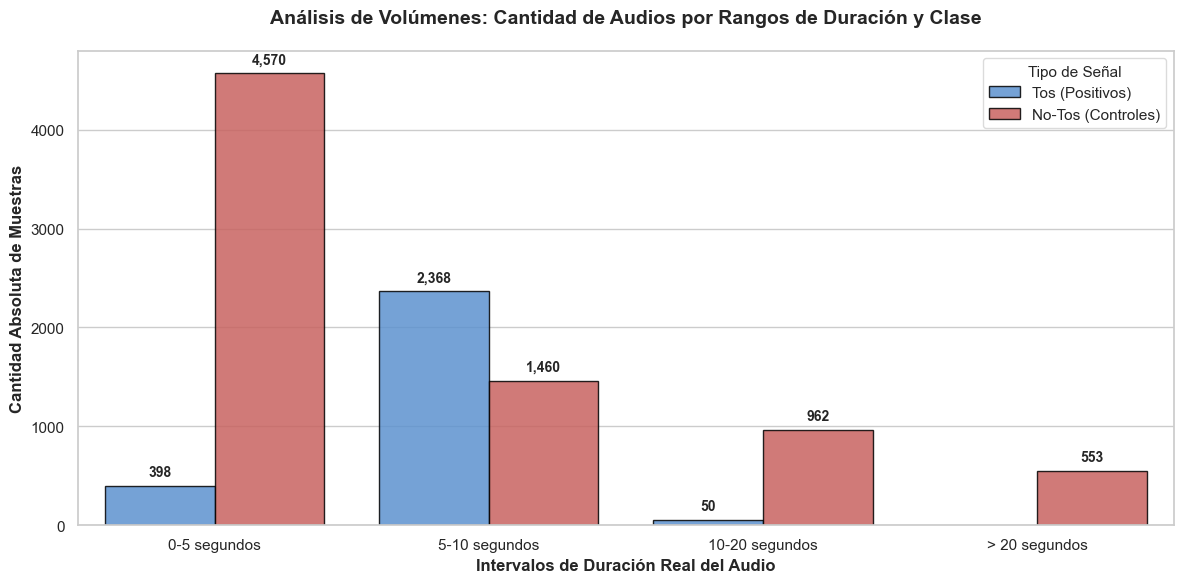

🎧 LISTA DE CONTROL: TOSEDORES ENTRE 10 Y 20 SEGUNDOS (Total: 51)
Nº    | UUID del Archivo                         | Duración Real  
-----------------------------------------------------------------
1     | 1b25273d-6761-47f7-b1e3-36ed0d0b4701     | 13.68 segundos
2     | 1f02c230-3a22-4ee1-81e4-7e7237b36c03     | 10.02 segundos
3     | 1f6a497a-7d48-4db2-be34-c7760e427427     | 13.08 segundos
4     | 2a1cf069-7f78-4c41-96a0-3a786767ee7b     | 10.02 segundos
5     | 2dd7dcf1-1065-4779-98ae-7e152ca3b1d5     | 10.01 segundos
6     | 34191fb6-7fb8-4cbf-a5cf-ea458bf4107b     | 10.02 segundos
7     | 34ed92ba-3dbd-4f66-9ded-3f6e6261b14b     | 10.02 segundos
8     | 3b2028a4-f2e5-4462-b618-7d5240be8af7     | 10.02 segundos
9     | 3e6c4fe1-b681-48d7-a576-5c4ddee41c70     | 10.01 segundos
10    | 47041a03-16e8-4a03-b343-8d5e69afcd5c     | 10.02 segundos
11    | 48f84033-8615-4805-b2a5-d84050d3951b     | 10.00 segundos
12    | 498d64dc-e551-4fe1-8da3-ba533134d950     | 10.02 segundos
13    | 4a

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Crear intervalos de tiempo discretos (bins) para poder hacer el gráfico de barras
bins = [0, 5, 10, 20, float('inf')]
labels = ['0-5 segundos', '5-10 segundos', '10-20 segundos', '> 20 segundos']

# Clonamos el dataframe de trabajo para no alterar el original
df_visual = df_maestro.copy()
df_visual['rango_duracion'] = pd.cut(df_visual['duration'], bins=bins, labels=labels)

# Traducir la etiqueta a texto legible para el gráfico
df_visual['Clase'] = df_visual['label'].map({0: 'No-Tos (Controles)', 1: 'Tos (Positivos)'})

# 2. Configurar la figura y el estilo
sns.set_theme(style='whitegrid')
plt.figure(figsize=(12, 6))

# 3. Dibujar el gráfico de barras conteo agrupado por clase
ax = sns.countplot(
    data=df_visual,
    x='rango_duracion',
    hue='Clase',
    palette=['#4a90e2', '#d9534f'], # Azul para controles, Rojo para toses
    edgecolor='black',
    alpha=0.85
)

# 4. Añadir los números exactos encima de cada barra para tener control total
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(
            f'{int(height):,}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=10, fontweight='bold',
            xytext=(0, 5),
            textcoords='offset points'
        )

# 5. Personalización estética y académica
plt.title('Análisis de Volúmenes: Cantidad de Audios por Rangos de Duración y Clase', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Intervalos de Duración Real del Audio', fontsize=12, fontweight='bold')
plt.ylabel('Cantidad Absoluta de Muestras', fontsize=12, fontweight='bold')
plt.legend(title='Tipo de Señal', title_fontsize='11', loc='upper right', frameon=True, facecolor='white', edgecolor='#d3d3d3')

plt.tight_layout()

# Guardar la nueva gráfica en tu directorio de experimentos
os.makedirs('graphs_results_experiments', exist_ok=True)
plt.savefig('graphs_results_experiments/barras_duracion_por_clase.png', dpi=300, bbox_inches='tight')
plt.show()


# 1. Filtrar el DataFrame según tus condiciones estrictas
# Label == 1 (Toses) y duración estrictamente entre 10 y 20 segundos
filtro_toses_largas = (df_maestro['label'] == 1) & (df_maestro['duration'] >= 10) & (df_maestro['duration'] <= 20)
df_auditoria = df_maestro[filtro_toses_largas]

total_encontrados = len(df_auditoria)

print("=" * 80)
print(f"🎧 LISTA DE CONTROL: TOSEDORES ENTRE 10 Y 20 SEGUNDOS (Total: {total_encontrados})")
print("=" * 80)

if total_encontrados == 0:
    print("ℹ️ No se encontraron audios de tipo Tos (label 1) en ese rango de tiempo.")
else:
    # 2. Iterar y printear con su duración real al lado para que elijas cuáles escuchar
    print(f"{'Nº':<5} | {'UUID del Archivo':<40} | {'Duración Real':<15}")
    print("-" * 65)
    
    for idx, (_, row) in enumerate(df_auditoria.iterrows(), 1):
        # Si la lista es gigantesca, puedes descomentar las siguientes dos líneas para capar el print a los primeros 30
        # if idx > 30: 
        #     print(f"... y otros {total_encontrados - 30} audios más.")
        #     break
            
        print(f"{idx:<5} | {row['uuid']:<40} | {row['duration']:.2f} segundos")

print("=" * 80)